import libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

Load Dataset

In [11]:
url = "https://raw.githubusercontent.com/plotly/datasets/master/finance-charts-apple.csv"

df = pd.read_csv(url)

print(df.shape)

df.head()

(506, 11)


,Date,AAPL.Open,AAPL.High,AAPL.Low,AAPL.Close,AAPL.Volume,AAPL.Adjusted,dn,mavg,up,direction
0,2015-02-17,127.489998,128.880005,126.919998,127.830002,63152400,122.905254,106.741052,117.927667,129.114281,Increasing
1,2015-02-18,127.629997,128.779999,127.449997,128.720001,44891700,123.760965,107.842423,118.940333,130.038244,Increasing
2,2015-02-19,128.479996,129.029999,128.330002,128.449997,37362400,123.501363,108.894245,119.889167,130.884089,Decreasing
3,2015-02-20,128.619995,129.500000,128.050003,129.500000,48948400,124.510914,109.785449,120.763500,131.741551,Increasing
4,2015-02-23,130.020004,133.000000,129.660004,133.000000,70974100,127.876074,110.372516,121.720167,133.067817,Increasing


Check Columns

In [12]:
print(df.columns)

Index(['Date', 'AAPL.Open', 'AAPL.High', 'AAPL.Low', 'AAPL.Close',
       'AAPL.Volume', 'AAPL.Adjusted', 'dn', 'mavg', 'up', 'direction'],
      dtype='object')


Select Closing Price

In [13]:
data = df['AAPL.Close']

print(data.head())

0    127.830002
1    128.720001
2    128.449997
3    129.500000
4    133.000000
Name: AAPL.Close, dtype: float64


Plot Stock Price

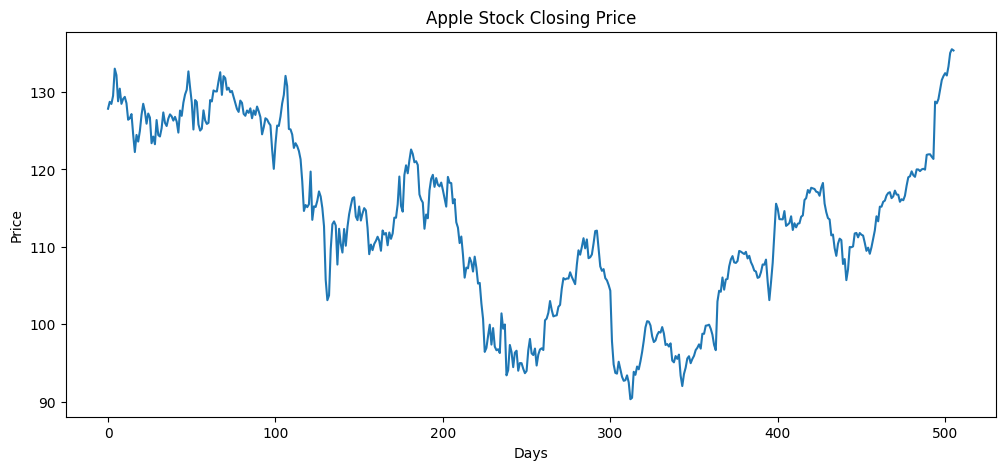

In [14]:
plt.figure(figsize=(12,5))

plt.plot(data)

plt.title("Apple Stock Closing Price")

plt.xlabel("Days")

plt.ylabel("Price")

plt.show()

Train-Test Split

In [15]:
train_size = int(len(data)*0.8)

train = data[:train_size]

test = data[train_size:]

print("Train Size =", len(train))

print("Test Size =", len(test))

Train Size = 404
Test Size = 102


Build ARIMA Model

In [16]:
model = ARIMA(
    train,
    order=(5,1,0)
)

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             AAPL.Close   No. Observations:                  404
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -804.918
Date:                Tue, 02 Jun 2026   AIC                           1621.836
Time:                        23:03:32   BIC                           1645.830
Sample:                             0   HQIC                          1631.335
                                - 404                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0040      0.045      0.089      0.929      -0.085       0.093
ar.L2         -0.0498      0.051     -0.986      0.324      -0.149       0.049
ar.L3         -0.0358      0.042     -0.847      0.3

Forecast

In [17]:
forecast = model_fit.forecast(
    steps=len(test)
)

print(forecast.head())

404    113.625269
405    113.742705
406    113.750492
407    113.743708
408    113.732991
Name: predicted_mean, dtype: float64


RMSE

In [19]:
rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

print("RMSE =", rmse)

RMSE = 7.3263296374327


Actual vs Predicted

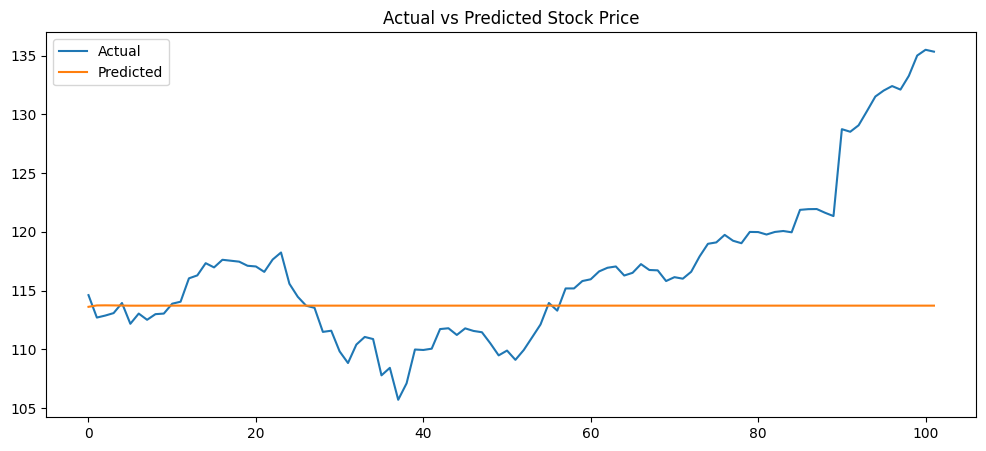

In [20]:
plt.figure(figsize=(12,5))

plt.plot(
    test.values,
    label="Actual"
)

plt.plot(
    forecast.values,
    label="Predicted"
)

plt.title(
    "Actual vs Predicted Stock Price"
)

plt.legend()

plt.show()